# 04 · Pairing and lineup

A lineup is three decisions: who tees off on odd holes, who partners whom, and the order of the five pairs. We measure how much each is worth. The main goal is expected points; we also report the chance of winning a fixture.

In [1]:
import sys
sys.path.insert(0, "..")
from itertools import combinations, permutations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.pipeline import build
from src.simulator import ShotModel, league_course, hole_pmfs, pair_vs_pair, CATEGORIES
from src.lineup import (role_shot_counts, role_values, pair_edge, best_orientation, outcome_curve,
                        match_from_edges, fixture_from_edges, best_role_split, recommend_lineup)
from src.viz import set_style, PALETTE, NEUTRAL, INK_2

set_style()
pd.set_option("display.width", 200)

P = build()
ratings, rounds = P["ratings"], P["rounds"]
model = ShotModel.build(P["shots"], ratings)
course = league_course(P["course_holes"], P["shots"])

## Which shots each role hits

,OTT,APP,ARG,PUTT,total
odd,6.04,11.25,3.37,14.99,35.66
even,8.03,6.39,6.77,14.04,35.23


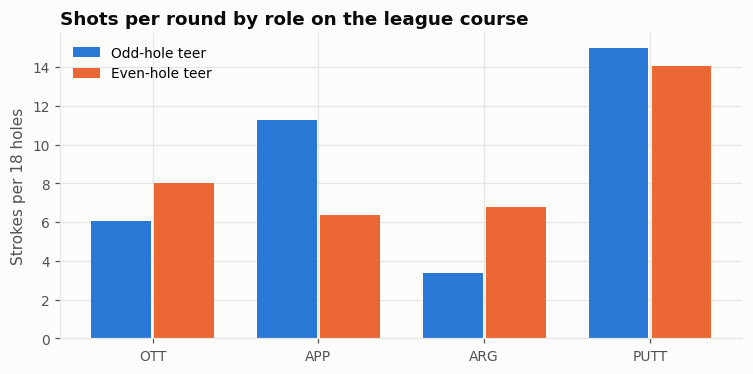

In [2]:
counts = role_shot_counts(model, course)
display(counts.round(2).assign(total=counts.sum(axis=1).round(2)))

fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(4); w = 0.36
ax.bar(x - w / 2 - 0.01, counts.loc["odd"], w, color=PALETTE[0], label="Odd-hole teer")
ax.bar(x + w / 2 + 0.01, counts.loc["even"], w, color=PALETTE[1], label="Even-hole teer")
ax.set_xticks(x); ax.set_xticklabels(CATEGORIES)
ax.set(title="Shots per round by role on the league course", ylabel="Strokes per 18 holes")
ax.legend(loc="upper left")
plt.show()

The odd-hole player hits nearly twice as many approach shots (the par-3 tee shots). The even-hole player hits more drives and twice as many short-game shots. Next: use this to rate pairs quickly.

## A quick formula for pair strength

Shots per role × each player's skill per shot, added up. We check it against the full simulator.

r = 0.998 · slope 1.005 · mean abs gap 0.030 strokes/round


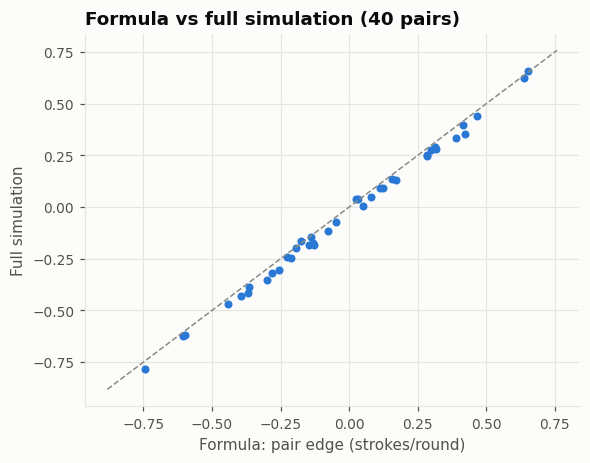

In [3]:
values = role_values(model, counts, ratings.index)
rng = np.random.default_rng(3)
ids = ratings.index.to_numpy()
base = hole_pmfs(model, course, (None, None), n=12000, seed=5)
k = np.arange(base.shape[1]); e0 = (base * k).sum()
chk = []
for i in range(40):
    a, b = rng.choice(ids, 2, replace=False)
    pm = hole_pmfs(model, course, (a, b), n=12000, seed=5)
    chk.append({"full simulation": e0 - (pm * k).sum(), "formula": pair_edge(values, a, b)})
chk = pd.DataFrame(chk)
slope = np.polyfit(chk.formula, chk["full simulation"], 1)[0]
print(f"r = {chk.corr().iloc[0, 1]:.3f} · slope {slope:.3f} · mean abs gap {(chk.formula - chk['full simulation']).abs().mean():.3f} strokes/round")

fig, ax = plt.subplots(figsize=(5.8, 4.4))
ax.scatter(chk.formula, chk["full simulation"], s=18, color=PALETTE[0])
lim = [chk.min().min() - 0.1, chk.max().max() + 0.1]
ax.plot(lim, lim, color=NEUTRAL, lw=1, ls="--")
ax.set(title="Formula vs full simulation (40 pairs)", xlabel="Formula: pair edge (strokes/round)", ylabel="Full simulation")
plt.show()

It matches almost perfectly (r = 0.998) and is thousands of times faster. 

## Does mixing styles help?

For all 5,460 possible pairs: pair strength minus the simple average of the two players.

In [4]:
indiv = ratings[CATEGORIES].sum(axis=1)
rows = []
for a, b in combinations(ratings.index, 2):
    (o, e), edge = best_orientation(values, a, b)
    rows.append({"a": a, "b": b, "odd": o, "edge": edge, "simple_avg": (indiv[a] + indiv[b]) / 2,
                 "orientation_gain": abs(pair_edge(values, a, b) - pair_edge(values, b, a))})
pairs = pd.DataFrame(rows)
pairs["complementarity"] = pairs.edge - pairs.simple_avg
r2 = np.corrcoef(pairs.edge, pairs.simple_avg)[0, 1] ** 2
print(f"Share of pair strength explained by the simple average: {r2:.1%}")
pairs[["edge", "simple_avg", "complementarity", "orientation_gain"]].describe().loc[["mean", "std", "min", "max"]].round(3)

Share of pair strength explained by the simple average: 99.2%


,edge,simple_avg,complementarity,orientation_gain
mean,0.036,-0.000,0.036,0.072
std,0.327,0.325,0.029,0.059
min,-0.974,-1.100,-0.014,0.000
max,1.221,1.168,0.196,0.400


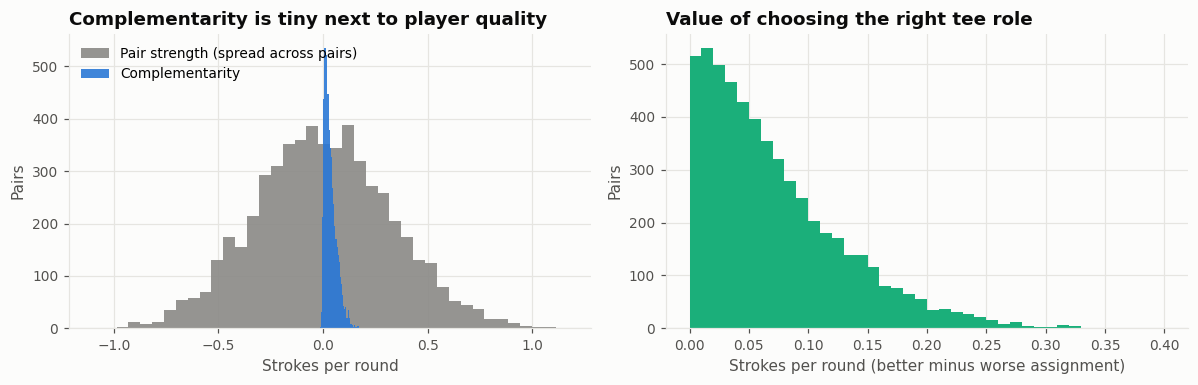

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
ax = axes[0]
ax.hist(pairs.simple_avg, bins=40, color=NEUTRAL, alpha=0.9, label="Pair strength (spread across pairs)")
ax.hist(pairs.complementarity, bins=40, color=PALETTE[0], alpha=0.9, label="Complementarity")
ax.set(title="Complementarity is tiny next to player quality", xlabel="Strokes per round", ylabel="Pairs")
ax.legend(loc="upper left")
ax = axes[1]
ax.hist(pairs.orientation_gain, bins=40, color=PALETTE[2])
ax.set(title="Value of choosing the right tee role", xlabel="Strokes per round (better minus worse assignment)", ylabel="Pairs")
plt.tight_layout(); plt.show()

In [6]:
top_syn = pairs.nlargest(5, "complementarity")
show = []
for r in top_syn.itertuples():
    ev = r.b if r.odd == r.a else r.a
    show.append({"odd-role player": ratings.loc[r.odd, CATEGORIES].round(2).to_dict(),
                 "even-role player": ratings.loc[ev, CATEGORIES].round(2).to_dict(),
                 "complementarity": round(r.complementarity, 3)})
pd.DataFrame(show)

,odd-role player,even-role player,complementarity
0,"{'OTT': -0.83, 'APP': 0.01, 'ARG': -0.26, 'PUT...","{'OTT': 0.07, 'APP': -0.36, 'ARG': 0.22, 'PUTT...",0.196
1,"{'OTT': -0.36, 'APP': 0.37, 'ARG': -0.04, 'PUT...","{'OTT': 0.07, 'APP': -0.36, 'ARG': 0.22, 'PUTT...",0.183
2,"{'OTT': -0.83, 'APP': 0.01, 'ARG': -0.26, 'PUT...","{'OTT': 0.3, 'APP': -0.12, 'ARG': 0.19, 'PUTT'...",0.168
3,"{'OTT': -0.83, 'APP': 0.01, 'ARG': -0.26, 'PUT...","{'OTT': 0.86, 'APP': 0.13, 'ARG': 0.12, 'PUTT'...",0.165
4,"{'OTT': -0.53, 'APP': 0.01, 'ARG': -0.19, 'PUT...","{'OTT': 0.07, 'APP': -0.36, 'ARG': 0.22, 'PUTT...",0.165


The simple average explains 99% of pair strength. Mixing styles adds very little. Picking the right tee roles adds a bit more. 

## "Who partners whom does not matter"

Add up five pairs and the total depends only on who takes the odd holes. So pairing cannot change expected points, only the role split can. We compare the best role split with a simple rule for ten seed-drafted teams.

In [7]:
order_ = ratings.sort_values("seed").index.tolist()
teams = {t: [] for t in range(1, 11)}
for r in range(10):
    for t in (range(1, 11) if r % 2 == 0 else range(10, 0, -1)):
        teams[t].append(order_.pop(0))

rows = []
for t, ros in teams.items():
    _, _, best = best_role_split(values, ros)
    worst = -best_role_split(-values, ros)[2]
    s = sorted(ros, key=lambda p: ratings.seed[p])
    naive = sum(values.at[s[2 * i], "odd"] + values.at[s[2 * i + 1], "even"] for i in range(5))
    rows.append({"team": t, "optimal roles": best, "naive roles": naive, "worst roles": worst})
roles_tbl = pd.DataFrame(rows).set_index("team")
roles_tbl["gain vs naive"] = roles_tbl["optimal roles"] - roles_tbl["naive roles"]
display(roles_tbl.round(2))
print(f"Average gain from optimal roles: {roles_tbl['gain vs naive'].mean():+.2f} strokes per round, summed over the 5 pairs")

,optimal roles,naive roles,worst roles,gain vs naive
team,,,,
1,0.01,-0.14,-0.40,0.15
2,0.95,0.65,0.43,0.30
3,0.65,0.47,0.22,0.19
4,1.27,1.15,0.98,0.12
5,-0.69,-1.19,-1.31,0.50
6,-0.59,-0.91,-1.03,0.33
7,0.29,-0.06,-0.13,0.35
8,0.43,-0.22,-0.30,0.66
9,0.44,0.35,0.18,0.09


Average gain from optimal roles: +0.31 strokes per round, summed over the 5 pairs


Good roles add about 0.3 strokes per round per lineup, for free. Team strength itself ranges from −0.7 to +1.3, which is much bigger. 

## From pair strength to match odds

One calibration curve from the simulator, then any match is read off it.

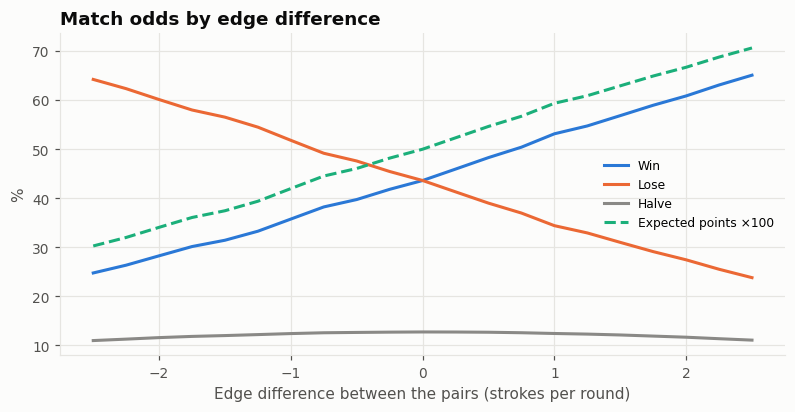

Mean absolute gap on 12 real matchups: 0.0048 points


,edge difference,points (full sim),points (curve)
0,-0.315,0.473,0.476
1,0.171,0.517,0.516
2,-0.377,0.471,0.471
3,-0.138,0.492,0.490
4,0.673,0.557,0.561
5,0.891,0.577,0.582
6,0.396,0.539,0.537
7,-0.559,0.449,0.457
8,-0.464,0.453,0.464
9,-0.352,0.464,0.473


In [8]:
curve = outcome_curve(model, course, edges=np.arange(-2.5, 2.51, 0.25), n=10000)
fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.plot(curve.index, curve.win * 100, color=PALETTE[0], label="Win")
ax.plot(curve.index, curve.lose * 100, color=PALETTE[1], label="Lose")
ax.plot(curve.index, curve.halve * 100, color=NEUTRAL, label="Halve")
pts = (curve.win + curve.halve / 2) * 100
ax.plot(curve.index, pts, color=PALETTE[2], ls="--", label="Expected points ×100")
ax.set(title="Match odds by edge difference", xlabel="Edge difference between the pairs (strokes per round)", ylabel="%")
ax.legend(loc="center right", fontsize=8)
plt.show()

rng = np.random.default_rng(9); rows = []
for i in range(12):
    a, b, c, d = rng.choice(ids, 4, replace=False)
    (pa, ea) = best_orientation(values, a, b); (pb, eb) = best_orientation(values, c, d)
    full = pair_vs_pair(model, course, pa, pb, n=8000, seed=i)
    ap = match_from_edges(ea, eb, curve)
    rows.append({"edge difference": ea - eb, "points (full sim)": full["A"] + full["halved"] / 2, "points (curve)": ap["A"] + ap["halved"] / 2})
val = pd.DataFrame(rows)
print(f"Mean absolute gap on 12 real matchups: {(val['points (full sim)'] - val['points (curve)']).abs().mean():.4f} points")
val.round(3)

The curve matches full simulations within 0.005 points, and it is almost a straight line. Next: does pairing or order change fixture wins?

## Pairing and order

All 120 pairings of a roster, with the opponent's order unknown and known.

In [9]:
def lineup_edges(odd, even, m):
    return [values.at[odd[i], "odd"] + values.at[even[m[i]], "even"] for i in range(5)]

results = {}
for A, B in [(1, 10), (3, 8)]:
    oa, ea, _ = best_role_split(values, teams[A]); ob, eb, _ = best_role_split(values, teams[B])
    oa = sorted(oa, key=lambda p: -values.at[p, "odd"]); ea = sorted(ea, key=lambda p: -values.at[p, "even"])
    ob = sorted(ob, key=lambda p: -values.at[p, "odd"]); eb = sorted(eb, key=lambda p: -values.at[p, "even"])
    opp = sorted(lineup_edges(ob, eb, range(5)), reverse=True)
    rows = []
    for m in permutations(range(5)):
        e = lineup_edges(oa, ea, m)
        unk = [fixture_from_edges(e, list(op), curve) for op in permutations(opp)]
        best_o = max(permutations(e), key=lambda oe: fixture_from_edges(list(oe), opp, curve)["A_win"])
        rows.append({"matching": m, "pair spread": np.std(e),
                     "exp points (order unknown)": np.mean([u["exp_points_A"] for u in unk]),
                     "win % (order unknown)": np.mean([u["A_win"] for u in unk]) * 100,
                     "win % (best response)": fixture_from_edges(list(best_o), opp, curve)["A_win"] * 100,
                     "win % (strong vs strong)": fixture_from_edges(sorted(e, reverse=True), opp, curve)["A_win"] * 100})
    results[(A, B)] = pd.DataFrame(rows)

summary = pd.concat({f"Team {A} vs Team {B}": d.drop(columns=["matching", "pair spread"]).agg(["min", "max"]).T
                     for (A, B), d in results.items()}, axis=1)
summary.round(3)

Team 1 vs Team 10         Team 3 vs Team 8        
                                         min     max              min     max
exp points (order unknown)             2.456   2.463            2.533   2.537
win % (order unknown)                 40.996  41.234           43.940  44.087
win % (best response)                 41.115  41.599           44.104  44.508
win % (strong vs strong)              40.749  40.909           43.540  43.813

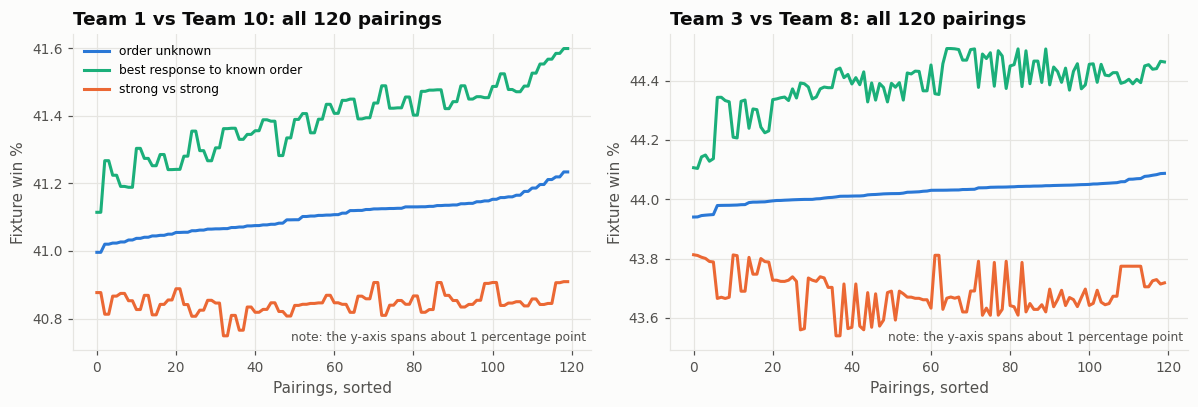

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=False)
for ax, ((A, B), d) in zip(axes, results.items()):
    d = d.sort_values("win % (order unknown)").reset_index(drop=True)
    ax.plot(d.index, d["win % (order unknown)"], color=PALETTE[0], label="order unknown")
    ax.plot(d.index, d["win % (best response)"], color=PALETTE[2], label="best response to known order")
    ax.plot(d.index, d["win % (strong vs strong)"], color=PALETTE[1], label="strong vs strong")
    ax.set(title=f"Team {A} vs Team {B}: all 120 pairings", xlabel="Pairings, sorted", ylabel="Fixture win %")
    ax.text(0.99, 0.02, "note: the y-axis spans about 1 percentage point", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=8, color=INK_2)
axes[0].legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

Expected points barely move. Win chances move by a few tenths of a percentage point. Knowing the opponent's order and sacrificing one slot (Tian Ji style) adds under one percentage point. It works for horses because the stronger horse almost always wins; in golf, luck makes the odds curve almost straight.

## Robustness

In [11]:
rng = np.random.default_rng(0)
ros = teams[1]
o0, e0_, _ = best_role_split(values, ros)
chosen, regret = [], []
for _ in range(500):
    draw = pd.DataFrame({c: rng.normal(ratings.loc[ros, c], ratings.loc[ros, c + "_sd"]) for c in CATEGORIES}, index=ros)
    s = draw.div(model.strokes_per_round, axis=1)
    vd = pd.DataFrame({"odd": s @ counts.loc["odd"], "even": s @ counts.loc["even"]})
    o, e, b = best_role_split(vd, ros)
    chosen.append(set(o))
    regret.append(b - (vd.loc[o0, "odd"].sum() + vd.loc[e0_, "even"].sum()))
freq = pd.Series({p: np.mean([p in c for c in chosen]) for p in ros}, name="share of draws in odd role")
print(f"Expected regret of using the point estimate: {np.mean(regret):.3f} strokes per round (95th percentile {np.percentile(regret, 95):.2f})")
freq.to_frame().assign(seed=ratings.loc[ros, "seed"]).sort_values("share of draws in odd role").round(2)

Expected regret of using the point estimate: 0.126 strokes per round (95th percentile 0.31)


,share of draws in odd role,seed
038e1fbfb9,0.17,1
2fc570193b,0.22,41
d5be1cb092,0.30,20
720acb654c,0.35,80
a4b47a4b14,0.42,60
e45fef8c37,0.47,100
57c8720352,0.65,40
9db6a7a9c4,0.66,21
79c8276c30,0.82,81
d9e6b1ddaf,0.94,61


Rating uncertainty costs about 0.1 strokes in role choice, which is small. Next: is volatility a real trait?

In [12]:
r = rounds.copy()
r["resid"] = r.sg_total - r.player_id.map(ratings.total)
r["half"] = r.groupby("player_id").cumcount() % 2
sd_half = r.groupby(["player_id", "half"]).resid.std().unstack()
sd_year = r.assign(yr=r.date.dt.year).groupby(["player_id", "yr"]).resid.std().unstack().dropna()
print(f"Split-half correlation of player volatility: {sd_half.corr().iloc[0, 1]:.2f}")
print(f"2022 vs 2023 correlation of player volatility: {sd_year.corr().iloc[0, 1]:.2f}")

Split-half correlation of player volatility: 0.07
2022 vs 2023 correlation of player volatility: 0.09


No. It barely repeats between halves of the data, so we do not use it.

## Lineup recommender

Best roles, then the pairing with the best win chance, then a best-response order if we know the opponent's.

In [13]:
rec = recommend_lineup(values, teams[1], curve)
rec_named = rec.assign(odd_seed=rec.odd_tee.map(ratings.seed), even_seed=rec.even_tee.map(ratings.seed))
print(f"vs league-average opponent: win {rec.attrs['win']:.1%}, draw {rec.attrs['draw']:.1%}, expected points {rec.attrs['exp_points']:.2f}")
display(rec_named.round(3))

ob, eb, _ = best_role_split(values, teams[10])
ob = sorted(ob, key=lambda p: -values.at[p, "odd"]); eb = sorted(eb, key=lambda p: -values.at[p, "even"])
opp10 = sorted(lineup_edges(ob, eb, range(5)), reverse=True)
rec2 = recommend_lineup(values, teams[1], curve, opponent_edges=opp10)
print(f"vs Team 10 (known order, pair edges {np.round(opp10, 2).tolist()}): win {rec2.attrs['win']:.1%}, expected points {rec2.attrs['exp_points']:.2f}")
rec2.assign(odd_seed=rec2.odd_tee.map(ratings.seed), even_seed=rec2.even_tee.map(ratings.seed), opponent_edge=opp10).round(3)

vs league-average opponent: win 43.3%, draw 14.7%, expected points 2.52


,odd_tee,even_tee,pair_edge,odd_seed,even_seed
slot,,,,,
1,e45fef8c37,038e1fbfb9,0.486,100,1
2,d9e6b1ddaf,2fc570193b,0.278,61,41
3,57c8720352,720acb654c,-0.216,40,80
4,9db6a7a9c4,d5be1cb092,-0.260,21,20
5,79c8276c30,a4b47a4b14,-0.276,81,60


vs Team 10 (known order, pair edges [0.53, 0.43, 0.05, -0.05, -0.29]): win 41.6%, expected points 2.47


,odd_tee,even_tee,pair_edge,odd_seed,even_seed,opponent_edge
slot,,,,,,
1,57c8720352,720acb654c,-0.216,40,80,0.529
2,79c8276c30,a4b47a4b14,-0.276,81,60,0.430
3,9db6a7a9c4,d5be1cb092,-0.260,21,20,0.054
4,e45fef8c37,2fc570193b,0.109,100,41,-0.049
5,d9e6b1ddaf,038e1fbfb9,0.655,61,1,-0.292


Clever pairing and ordering only move strength around. The value is in who is on the roster, which is notebook 05.